# tiny-yolov3-coco sur kitti — inférence

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lrivals/EmbeddedComputervision/blob/main/notebooks/kitti/tiny-yolov3-coco_infer.ipynb)

Rôle : inférence ; palier **R** au premier passage (`SUBSET = 50`), **N** sur le split complet (1496 images, `SUBSET = 0`). Tâches : [T11.2](../../docs/tasks/M11-jeux-de-donnees.md) ;
notebooks : [M14](../../docs/tasks/M14-notebooks.md). Poids COCO hors domaine : seules les classes communes sont évaluées.

Prérequis :
- données : `data/kitti/training/image_2/000000.png` — tools/get_datasets.sh kitti
- poids : `weights/yolov3-tiny.weights` — tools/get_weights.sh

Chaque étape affiche la commande `python tools/…` qu'elle lance : un résultat se
reproduit en ligne de commande. Sorties dans `build/notebooks/kitti/tiny-yolov3-coco/`, jamais dans `results/`
(une mAP sur `SUBSET` images n'est pas publiable, règles de M12). Notebook généré par
`python -m tools.notebooks` (`make notebooks`) : modifier le gabarit
`tools/notebooks/gabarits.py`, pas ce fichier.

## Paramètres

In [1]:
NET          = 'tiny-yolov3-coco'  # nom de CFG_FILES ou cfg (relative à la racine)
DATASET      = 'kitti'  # clé de DATASETS
SPLIT        = None  # None : split d'évaluation du jeu
WEIGHTS      = 'weights/yolov3-tiny.weights'  # poids évalués
DEVICE       = 'cpu'  # cpu | gpu (entraînement seulement ; le reste sur CPU)
SUBSET       = 50  # images évaluées ; 0 : split complet (palier N)
SIZE         = None  # entrée LxH (ex. '640x192') ; None : celle de la cfg
RESIZE       = 'stretch'  # stretch (référence M12) | letterbox
METRIC       = None  # None : celle du jeu (coco pour coco et flir)
DATA_ROOT    = None  # racine du jeu ; None : data/<jeu> (Colab : dossier Drive)
INT8         = False  # volet entier : calibration et mAP INT8 (T14.4)
CALIB_IMAGES = 500  # images de calibration (split calib du jeu)
ACT_HIST     = False  # histogrammes d'activations L00-L04 (T11.3)
DRIVE_DIR    = '/content/drive/MyDrive/EmbeddedCV'  # Colab : archives data/<jeu>.tar ; None : pas de Drive
JOBS         = 4  # processus des évaluations
SHOW         = 6  # images affichées
OUT          = 'build/notebooks/kitti/tiny-yolov3-coco'  # sorties du notebook
REPO_URL     = 'https://github.com/lrivals/EmbeddedComputervision.git'  # Colab : dépôt cloné
REV          = 'main'  # Colab : révision

## Environnement

Local : rien n'est installé ni téléchargé, la cellule vérifie les prérequis et
s'arrête avec la commande à lancer. Colab : clone du dépôt, installation, CuPy si
`DEVICE = "gpu"`, poids, puis données par `colab.prepare_data` (archive
`<DRIVE_DIR>/data/<jeu>.tar` ou téléchargement direct ; ExDark et FLIR : archive
seulement, faite sur le PC par `tools/get_datasets.sh pack <jeu>`).

In [2]:
import os
import subprocess
import sys
from pathlib import Path

COLAB = "google.colab" in sys.modules


def repo_root():
    for d in (Path.cwd(), *Path.cwd().parents):
        if (d / "tools" / "notebooks" / "commandes.py").exists():
            return d
    return None


ROOT = repo_root()
if COLAB:
    if ROOT is None:
        ROOT = Path("/content/EmbeddedComputervision")
        if not ROOT.exists():
            subprocess.run(["git", "clone", REPO_URL, str(ROOT)], check=True)
    # Clone d'une session précédente : remis à REV (notebook et code du même commit).
    subprocess.run(["git", "-C", str(ROOT), "fetch", "-q", "origin", REV], check=True)
    subprocess.run(["git", "-C", str(ROOT), "checkout", "-q", "FETCH_HEAD"], check=True)
    for m in [m for m in sys.modules if m.split(".")[0] in ("tools", "yolo")]:
        del sys.modules[m]  # modules importés avant la mise à jour
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e",
                    f"{ROOT}/python[data,plots]"], check=True)
    if DEVICE == "gpu":
        # Runtime CPU : pas de pilote, CuPy dirait « cudaErrorInsufficientDriver ».
        try:
            smi = subprocess.run(["nvidia-smi"], capture_output=True, text=True)
        except FileNotFoundError:
            smi = None
        if smi is None or smi.returncode != 0:
            raise RuntimeError("runtime Colab sans GPU : créer un nouveau serveur Colab "
                               "de type GPU (T4, L4 ou A100), ou DEVICE = 'cpu'")
        cuda = smi.stdout.split("CUDA Version:")[-1].split()[0]  # version du pilote
        cupy_pkg = "cupy-cuda13x" if int(cuda.split(".")[0]) >= 13 else "cupy-cuda12x"
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", cupy_pkg],
                       check=True)
elif ROOT is None:
    raise RuntimeError("racine du dépôt introuvable : ouvrir le notebook depuis notebooks/")
os.chdir(ROOT)
for p in (ROOT, ROOT / "python"):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from tools.notebooks import commandes as C
from tools.notebooks import env

TRACE = env.trace(DEVICE)
env.check_device(DEVICE)
env.prepare(DATASET, WEIGHTS, NET, DATA_ROOT, COLAB, hint='tools/get_weights.sh',
            drive_dir=DRIVE_DIR)
Path(OUT).mkdir(parents=True, exist_ok=True)

dépôt /content/EmbeddedComputervision @ 9a76534 ; Python 3.13.15 ; NumPy 2.1.3 ; backend cpu
données kitti : data/kitti/training/image_2/000000.png ; poids : weights/yolov3-tiny.weights


## Réseau et poids

`yolo.models.tiny_yolo.build` et `yolo.io.darknet_weights.load_darknet_weights`.

In [3]:
import json

import numpy as np
from IPython.display import Markdown, display
from PIL import Image

from tools.detect import draw
from tools.notebooks.matrice import SPLIT_IMAGES, palier
from yolo.data import datasets
from yolo.data.letterbox import input_size, parse_size, size_label
from yolo.infer.pipeline import detect, preprocess
from yolo.io.darknet_weights import load_darknet_weights
from yolo.models.tiny_yolo import build

net = build(NET)
load_darknet_weights(net, WEIGHTS)
size = input_size(net.net, parse_size(SIZE) if SIZE else None)
channels = net.net["input"][0]
family, names = datasets.model_family(DATASET, net.net["classes"])
print(f"{NET} : {net.net['classes']} classes ({family}), entrée {size_label(size)}, "
      f"{channels} canal(aux) ; poids {WEIGHTS}")

tiny-yolov3-coco : 80 classes (coco), entrée 416×416, 3 canal(aux) ; poids weights/yolov3-tiny.weights


## Détections sur quelques images

`yolo.infer.pipeline.preprocess` et `detect` (seuil de la démo), boîtes de
`tools/detect.py:draw`.

000004 : 0 détections


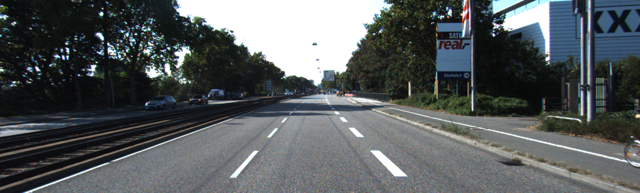

000012 : 2 détections


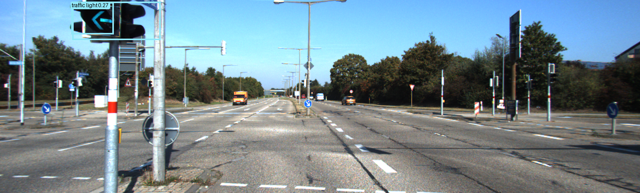

000014 : 0 détections


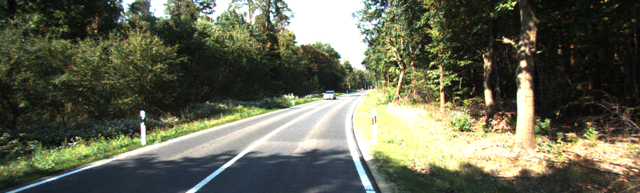

000015 : 4 détections


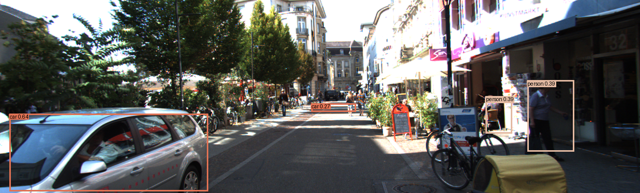

000017 : 1 détections


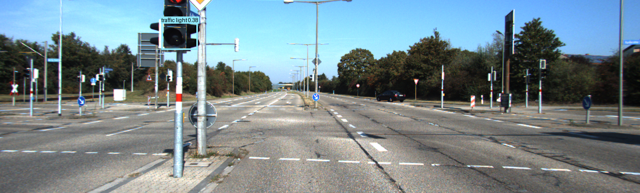

000030 : 0 détections


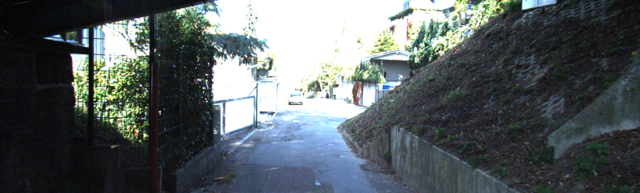

In [4]:
for s in datasets.load(DATASET, DATA_ROOT, SPLIT)[:SHOW]:
    with Image.open(s["image"]) as img:
        x, wh = preprocess(img, size, RESIZE, "pil", channels)
        boxes, scores, labels = detect(net, x[None], [wh], RESIZE)[0]
        shown = draw(img, boxes, scores, labels, names)
    shown.thumbnail((640, 640))
    print(f"{s['id']} : {len(labels)} détections")
    display(shown)

## Correspondance des classes (hors domaine, T11.2)

`MAPPINGS` de `yolo.data.datasets`, telle quelle ; les classes du jeu sans
équivalent sont retirées des vérités, les détections des autres classes du
modèle sont ignorées (`eval_view`).

In [5]:
view = datasets.eval_view(DATASET, net.net["classes"])
mapping = datasets.MAPPINGS[(DATASET, family)]
rows = ["| classe du jeu | classe du modèle |", "|---|---|"]
rows += [f"| {c} | {mapping.get(c, '— (sans équivalent, ignorée)')} |"
         for c in datasets.DATASETS[DATASET].classes]
display(Markdown("\n".join(rows)))
print(f"classes évaluées ({len(view.names)}) : {', '.join(view.names)}")
print(f"classes du modèle ignorées : {len(names) - len(view.names)}")

| classe du jeu | classe du modèle |
|---|---|
| Car | car |
| Van | car |
| Truck | truck |
| Pedestrian | person |
| Person_sitting | person |
| Cyclist | — (sans équivalent, ignorée) |
| Tram | train |
| Misc | — (sans équivalent, ignorée) |

classes évaluées (4) : person, car, train, truck
classes du modèle ignorées : 76


## mAP flottante (T14.3)

`tools/eval_voc.py`, métrique du jeu (`Dataset.metric` ; COCO et FLIR : AP@[.5:.95]
et AP50). Courbes PR du mode automatique de M13 (métrique VOC).

50 images : palier R (règles de M12)
$ python tools/eval_voc.py --net tiny-yolov3-coco --weights weights/yolov3-tiny.weights --dataset kitti --resize stretch --subset 50 --out build/notebooks/kitti/tiny-yolov3-coco/dets --markdown build/notebooks/kitti/tiny-yolov3-coco/map_float.md
50/50 images      14 s  (275 ms/image)
détections : build/notebooks/kitti/tiny-yolov3-coco/dets
### tiny-yolov3-coco (yolov3-tiny.weights), kitti val, 50 images, 416×416 stretch (pil), conf 0.005, NMS 0.45, AP 11 points

| Classe | AP |
|---|---|
| person | 15.5 |
| car | 49.7 |
| train | 7.9 |
| truck | 9.1 |
| **mAP** | **20.55** |

figures : build/notebooks/kitti/tiny-yolov3-coco/dets/figures/pr.png
  (16 s)


### tiny-yolov3-coco (yolov3-tiny.weights), kitti val, 50 images, 416×416 stretch (pil), conf 0.005, NMS 0.45, AP 11 points

| Classe | AP |
|---|---|
| person | 15.5 |
| car | 49.7 |
| train | 7.9 |
| truck | 9.1 |
| **mAP** | **20.55** |



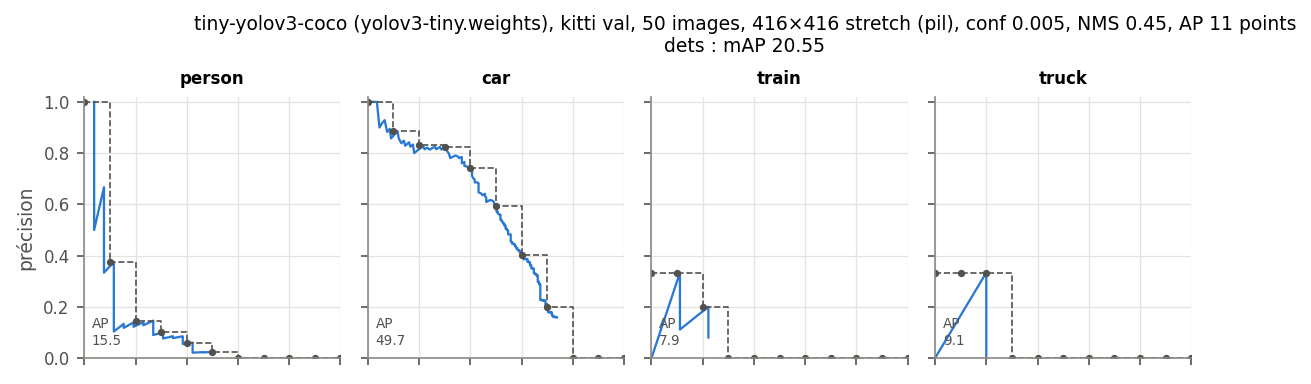

In [6]:
print(f"{SUBSET or 'toutes les'} images : palier "
      f"{palier(SUBSET or SPLIT_IMAGES.get(DATASET))} (règles de M12)")
map_float = Path(OUT) / "map_float.md"
map_float.unlink(missing_ok=True)
C.run(C.cmd_eval_voc(NET, WEIGHTS, DATASET, RESIZE, SUBSET, METRIC, SPLIT, SIZE,
                     DATA_ROOT, out=f"{OUT}/dets", markdown=map_float))
display(Markdown(map_float.read_text()))
for png in sorted(Path(OUT, "dets", "figures").glob("pr*.png")):
    display(Image.open(png))

## Volet entier (T14.4)

Activé par `INT8 = True`. Calibration par `tools/calibrate.py` sur le split `calib`
du jeu (échelles et rapport dans `OUT`, pas dans `results/`), puis
`tools/eval_quant.py --variants float,int`. Sur le split complet (`SUBSET = 0`),
palier **N** : compter 12 à 25 min pour VOC2007 test en plus de la calibration.

In [7]:
map_int = None
if INT8:
    if not SUBSET:
        print("SUBSET = 0 : split complet, palier N (plusieurs dizaines de minutes)")
    calib = Path(OUT) / "calib.json"
    C.run(C.cmd_calibrate(NET, WEIGHTS, DATASET, calib, Path(OUT) / "calibration.md",
                          CALIB_IMAGES, data_root=DATA_ROOT))
    map_int = Path(OUT) / f"map_{RESIZE}_{SUBSET or 'complet'}.json"
    C.run(C.cmd_eval_quant(NET, map_int, "float,int", SUBSET, JOBS, DATASET,
                           weights=WEIGHTS, calib=calib, metric=METRIC, split=SPLIT,
                           size=SIZE, data_root=DATA_ROOT))
    d = json.loads(map_int.read_text())
    fl, it = d["results"]["float"], d["results"]["int"]
    rows = ["| classe | flottant | entier | écart |", "|---|---|---|---|"]
    rows += [f"| {c} | {100 * a:.2f} | {100 * b:.2f} | {100 * (b - a):+.2f} |"
             for c, a, b in zip(d["classes"], fl["aps"], it["aps"])]
    rows.append(f"| **mAP** | **{100 * fl['map']:.2f}** | **{100 * it['map']:.2f}** | "
                f"{100 * (it['map'] - fl['map']):+.2f} |")
    display(Markdown(f"{d['images']} images, {d['metric']}\n\n" + "\n".join(rows)))
    for png in sorted((map_int.parent / "figures").glob(f"*{map_int.stem.removeprefix('map_')}*.png")):
        display(Image.open(png))
    if ACT_HIST:
        others = "voc" if DATASET == "voc" else f"voc,{DATASET}"
        C.run(C.cmd_act_hist(NET, WEIGHTS, others, calib, Path(OUT) / "act_hist"))
        display(Image.open(Path(OUT) / "act_hist" / "act_hist.png"))
else:
    print("INT8 = False : volet entier sauté")

INT8 = False : volet entier sauté


## Résumé

In [8]:
print(map_float.read_text())
if map_int:
    d = json.loads(map_int.read_text())
    for v, r in d["results"].items():
        print(f"{v:6s} mAP {100 * r['map']:.2f} ({d['images']} images)")
print(f"sorties : {OUT}/ ; révision {TRACE['rev']}")
print("commandes équivalentes :")
for c in C.HISTORY:
    print("  " + c)

### tiny-yolov3-coco (yolov3-tiny.weights), kitti val, 50 images, 416×416 stretch (pil), conf 0.005, NMS 0.45, AP 11 points

| Classe | AP |
|---|---|
| person | 15.5 |
| car | 49.7 |
| train | 7.9 |
| truck | 9.1 |
| **mAP** | **20.55** |


sorties : build/notebooks/kitti/tiny-yolov3-coco/ ; révision 9a76534
commandes équivalentes :
  python tools/eval_voc.py --net tiny-yolov3-coco --weights weights/yolov3-tiny.weights --dataset kitti --resize stretch --subset 50 --out build/notebooks/kitti/tiny-yolov3-coco/dets --markdown build/notebooks/kitti/tiny-yolov3-coco/map_float.md
